# **02 - Exploratory Data Analysis**

## Objectives

- Load and inspect the cleaned Online Retail Transaction dataset.
- Explore overall revenue and sales performance.
- Analyse revenue and sales volume over time.
- Investigate product and customer purchasing patterns.
- Compare geographic performance across countries.
- Explore relevant distributions and relationships within the data.
- Identify key insights that can support further visualisation and machine learning analysis.

## Inputs

- Cleaned Online Retail Transaction dataset produced during the ETL process and stored in the `outputs` folder.

## Outputs

- Exploratory analysis of the Online Retail Transaction dataset.
- Key findings and visualisations relating to revenue, sales volume, customers, products and geographic performance.
- Insights to support subsequent stages of the project.

## Additional Comments

- Analysis will be exploratory, with findings and interpretations documented throughout the notebook.

---

# Change working directory

In [1]:
import os

current_dir = os.getcwd()
print("Current directory:", current_dir)

if os.path.basename(current_dir) == "jupyter_notebooks":
    os.chdir(os.path.dirname(current_dir))
elif os.path.basename(current_dir) == "vscode-projects":
    os.chdir("Online Retail Transaction Analysis")

current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Current directory: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis/jupyter_notebooks
Working directory set to: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis


---

# Section 1 -  Import libraries

Here I will be importing the libraries that I will be using in this notebook.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")


---

# Section 2 - Load the dataset

Here I will load the cleaned Online Retail Transaction dataset that was produced during the ETL process.

In [3]:
df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")

/var/folders/cx/w0ydrn213c14xglf6wmp_2l00000gn/T/ipykernel_80113/3308739013.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")


In [4]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
Revenue        float64
dtype: object

The initial import produced a mixed data type warning for `InvoiceNo`. Inspection of the imported data types also showed that `InvoiceDate` had been loaded as an object rather than a datetime.

In [5]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'int'>    459342
<class 'str'>     65536
Name: count, dtype: int64

Further inspection showed that `InvoiceNo` contained both integer and string values. Since invoice numbers are identifiers rather than numerical measures, the column will be explicitly loaded as a string. `InvoiceDate` will also be parsed as a datetime to support time-based analysis.

In [6]:
df = pd.read_csv(
    "outputs/Online_Retail_Cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"],
)

In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Revenue               float64
dtype: object

In [8]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'str'>    524878
Name: count, dtype: int64

The corrected import confirms that all `InvoiceNo` values are now consistently loaded as strings and `InvoiceDate` has been successfully parsed as a datetime. The cleaned dataset is now loaded with appropriate data types for exploratory analysis.

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [10]:
print("Number of rows: ", df.shape[0])

Number of rows:  524878


In [11]:
print("Number of columns: ", df.shape[1])

Number of columns:  9


The dataset contains 524,878 records and 9 columns, matching the final dataset produced during the ETL process. An initial preview also confirms that the cleaned data and engineered `Revenue` feature have loaded successfully and are ready for exploratory analysis.

---

# Section 3 - Overall Business Performance

In this section, I will explore the overall business performance of the Online Retail Transaction dataset. This will include an analysis of total revenue, sales volume and other key metrics to provide an overview of the business's performance.

In [12]:
total_revenue = df["Revenue"].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 10,642,110.80


The total revenue generated across the cleaned transaction records is 10,642,110.80. This provides an overall measure of the revenue represented within the dataset and will be explored further across time periods, products, customers and countries.

In [13]:
total_sales_volume = df["Quantity"].sum()
print(f"Total Sales Volume: {total_sales_volume:,}")

Total Sales Volume: 5,572,420


A total of 5,572,420 units were sold across the cleaned transaction records. This represents the overall sales volume within the dataset and can later be explored across time periods, products and countries.

In [14]:
total_transactions = df["InvoiceNo"].nunique()
unique_customers = df["CustomerID"].nunique()

print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Customers: {unique_customers:,}")

Total Transactions: 19,960
Unique Customers: 4,338


The dataset contains 19,960 unique transactions across 4,338 unique customers. The difference between these figures indicates that customers can make multiple transactions, which will be investigated further during the customer purchasing behaviour analysis.

In [15]:
average_transaction = total_revenue / total_transactions

print(f"Average Transaction Value: {average_transaction:,.2f}")

Average Transaction Value: 533.17


The average transaction value across the dataset is 533.17. This represents the mean revenue generated per unique transaction. However, the average may be influenced by higher-value transactions, so the distribution of transaction values will be explored further during the analysis.

To provide a clear overview of the key business performance metrics calculated above, the results are summarised in a single DataFrame.

In [16]:
business_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Revenue",
            "Total Sales Volume",
            "Total Transactions",
            "Unique Customers",
            "Average Transaction Value",
        ],
        "Value": [
            total_revenue,
            total_sales_volume,
            total_transactions,
            unique_customers,
            average_transaction,
        ],
    }
)
business_summary

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Sales Volume,5.572420e+06
2,Total Transactions,1.996000e+04
3,Unique Customers,4.338000e+03
4,Average Transaction Value,5.331719e+02


Overall, the dataset contains transactions generating a total revenue of 10,642,110.80 from 5,572,420 units sold across 19,960 transactions and 4,338 unique customers. The average transaction value is 533.17. These metrics provide a baseline for further analysis of how performance varies over time, across products, customers and geographic regions.

---

# Section 4 - Revenue and Sales Volume Over Time

In this section, I will analyse how revenue and sales volume change over time. The transaction date range will first be examined to understand the period covered by the dataset. Monthly revenue and sales volume will then be analysed to identify trends, fluctuations and periods of higher or lower sales activity.

In [17]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [18]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

The dataset covers transactions from 1 December 2010 to 9 December 2011. This provides approximately one year of transaction data; however, December 2011 contains only partial-month data. This will be considered when interpreting monthly revenue and sales volume trends.

In [19]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [20]:
df[["InvoiceDate", "YearMonth"]].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


A `YearMonth` feature was created from `InvoiceDate` to support monthly trend analysis. Including both the year and month ensures that transactions from December 2010 and December 2011 are treated as separate periods.

In [21]:
df.groupby("YearMonth")["Revenue"].sum().reset_index()

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [22]:
monthly_performance = (
    df.groupby("YearMonth")[["Revenue", "Quantity"]].sum().reset_index()
)
monthly_performance

,YearMonth,Revenue,Quantity
0,2010-12,821452.730,358019
1,2011-01,689811.610,387099
2,2011-02,522545.560,282934
3,2011-03,716215.260,376599
4,2011-04,536968.491,307953
5,2011-05,769296.610,395001
6,2011-06,760547.010,388511
7,2011-07,718076.121,399693
8,2011-08,757841.380,421020
9,2011-09,1056435.192,569573


In [23]:
monthly_performance.dtypes

YearMonth    period[M]
Revenue        float64
Quantity         int64
dtype: object

The `YearMonth` column is stored as a pandas Period data type. To ensure compatibility with Seaborn when plotting the monthly trends, the column will be converted to a string for use as the x-axis labels.

In [24]:
monthly_performance["YearMonth"] = monthly_performance["YearMonth"].astype(str)

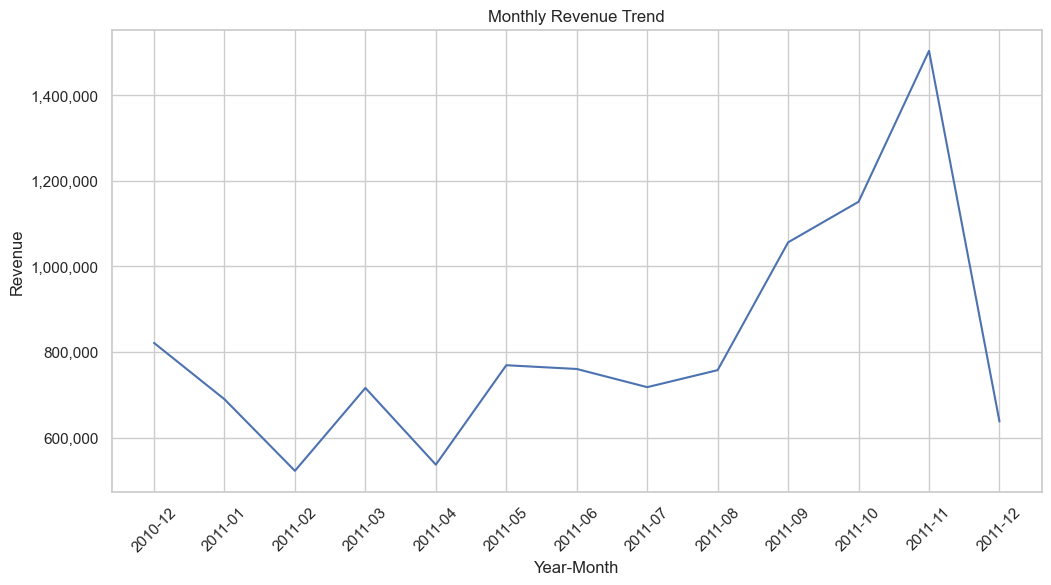

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Revenue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
revenue_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(revenue_formatter)
plt.show()

Monthly revenue fluctuates throughout the first half of the period, declining from December 2010 to February 2011 before recovering in March. Revenue falls again in April, followed by a stronger increase in May and relatively smaller fluctuations through to August.

A more substantial increase is visible from August onwards, with revenue rising sharply in September and continuing to increase through October before reaching its highest level in November 2011. This suggests that the strongest revenue performance within the complete monthly periods occurred towards the later months of 2011.

Revenue appears to fall substantially in December 2011; however, this should not be interpreted as a genuine decline in performance because the dataset only contains transactions up to 9 December. December 2011 is therefore an incomplete month and is not directly comparable with the complete monthly periods.

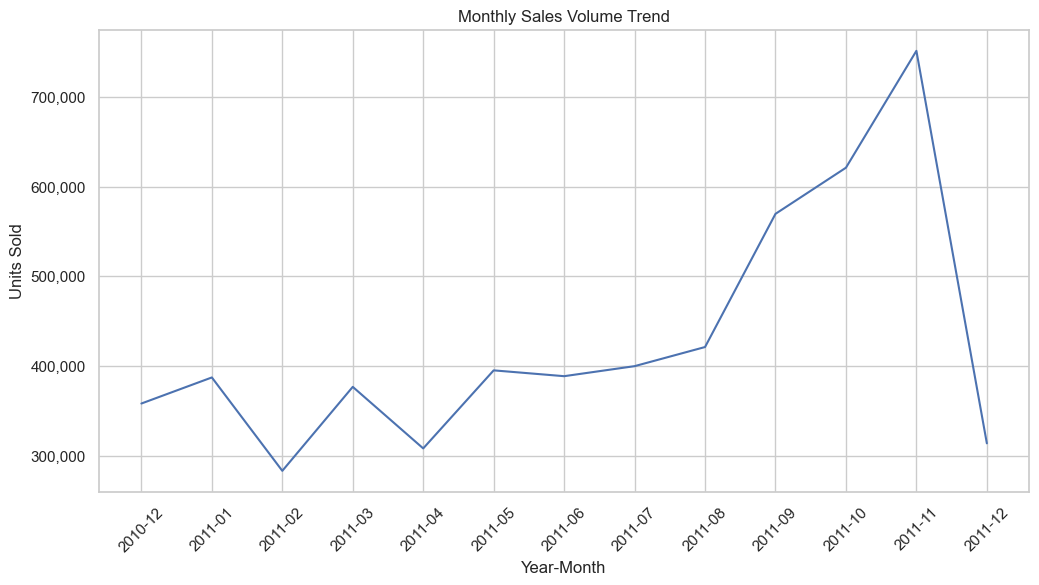

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Quantity")
plt.title("Monthly Sales Volume Trend")
plt.xlabel("Year-Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
quantity_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(quantity_formatter)
plt.show()

Monthly sales volume broadly follows a similar pattern to revenue, although the two measures do not move together in every period. Sales volume increases from December 2010 to January 2011 despite revenue decreasing over the same period. This is followed by a decline in February, an increase in March and another decline in April.

Sales volume recovers in May and remains relatively stable with smaller fluctuations through to August. From August onwards, sales activity increases substantially, with a sharp rise in September followed by further growth through October and November. November 2011 records the highest sales volume within the dataset.

The overall similarity between the revenue and sales volume trends suggests that higher quantities sold are generally associated with higher monthly revenue. However, periods such as December 2010 to January 2011 show that the relationship is not exact, suggesting that factors such as product prices and the mix of products purchased may also influence monthly revenue. The apparent decline in December 2011 should again be interpreted cautiously because the dataset only contains transactions up to 9 December.

---

# Section 5 - Product Performance

In this section, I will analyse product performance by examining sales volume, transaction frequency and revenue. This will help identify the strongest-performing products and determine whether high sales volumes reflect consistent demand or are influenced by unusually large individual orders.

In [27]:
unique_stock_codes = df["StockCode"].nunique()

In [28]:
unique_descriptions = df["Description"].nunique()

In [29]:
print(f"Unique Stock Codes: {unique_stock_codes:,}")
print(f"Unique Product Descriptions: {unique_descriptions:,}")

Unique Stock Codes: 3,922
Unique Product Descriptions: 4,026


In [30]:
stockcode_descriptions = df.groupby("StockCode")["Description"].nunique().reset_index()
stockcode_descriptions

,StockCode,Description
0,10002,1
1,10080,1
2,10120,1
3,10123C,1
4,10124A,1
...,...,...
3917,gift_0001_20,1
3918,gift_0001_30,1
3919,gift_0001_40,1
3920,gift_0001_50,1


In [31]:
stockcode_descriptions[stockcode_descriptions["Description"] > 1].sort_values(
    "Description", ascending=False
).head()

,StockCode,Description
2089,23236,4
2049,23196,4
104,17107D,3
1980,23126,3
2062,23209,3


In [32]:
df[df["StockCode"] == "23236"]["Description"].unique()

array(['DOILEY STORAGE TIN', 'DOILEY BISCUIT TIN',
       'STORAGE TIN VINTAGE DOILEY ', 'STORAGE TIN VINTAGE DOILY '],
      dtype=object)

In [33]:
df[df["StockCode"] == "23196"]["Description"].unique()

array(['RETRO LEAVES MAGNETIC NOTEPAD',
       'RETO LEAVES MAGNETIC SHOPPING LIST',
       'LEAVES MAGNETIC  SHOPPING LIST', 'VINTAGE LEAF MAGNETIC NOTEPAD'],
      dtype=object)

In [34]:
df[df["StockCode"] == "17107D"]["Description"].unique()

array(["FLOWER FAIRY,5 SUMMER B'DRAW LINERS",
       'FLOWER FAIRY 5 DRAWER LINERS',
       'FLOWER FAIRY 5 SUMMER DRAW LINERS'], dtype=object)

Before analysing product performance, `StockCode` and `Description` were examined to determine the most appropriate product identifier. The dataset contains 3,922 unique StockCodes and 4,026 unique product descriptions. Further investigation showed that some StockCodes are associated with multiple description variations. Therefore, `StockCode` will be used as the primary product identifier, while `Description` will be used to provide readable product labels.

In [35]:
top_products_quantity = (
    df.groupby("StockCode")["Quantity"]
    .agg(["sum", "max"])
    .reset_index()
    .sort_values("sum", ascending=False)
    .head()
)
top_products_quantity

,StockCode,sum,max
2465,23843,80995,80995
2020,23166,78033,74215
1109,22197,56898,4300
2909,84077,54951,4800
3387,85099B,48371,1200


In [36]:
(top_products_quantity["max"] / top_products_quantity["sum"]) * 100

2465    100.000000
2020     95.107198
1109      7.557383
2909      8.735055
3387      2.480825
dtype: float64

In [37]:
top_products_quantity["LargestOrderPercentage"] = (
    (top_products_quantity["max"] / top_products_quantity["sum"]) * 100
).round(2)
top_products_quantity

,StockCode,sum,max,LargestOrderPercentage
2465,23843,80995,80995,100.00
2020,23166,78033,74215,95.11
1109,22197,56898,4300,7.56
2909,84077,54951,4800,8.74
3387,85099B,48371,1200,2.48


In [38]:
product_transactions = (
    df.groupby("StockCode")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
    .head()
)
product_transactions

,StockCode,InvoiceNo
3407,85123A,2198
3387,85099B,2089
1310,22423,1988
2670,47566,1685
175,20725,1565


In [39]:
df[df["StockCode"] == "85099B"]["Description"].mode()

0    JUMBO BAG RED RETROSPOT
Name: Description, dtype: object

In [40]:
product_descriptions = (
    df.groupby("StockCode")["Description"].agg(lambda x: x.mode().iloc[0]).reset_index()
)

product_descriptions

,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE
...,...,...
3917,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00
3918,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00
3919,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00
3920,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00


In [41]:
product_transactions = product_transactions.merge(product_descriptions, on="StockCode")

product_transactions

,StockCode,InvoiceNo,Description
0,85123A,2198,WHITE HANGING HEART T-LIGHT HOLDER
1,85099B,2089,JUMBO BAG RED RETROSPOT
2,22423,1988,REGENCY CAKESTAND 3 TIER
3,47566,1685,PARTY BUNTING
4,20725,1565,LUNCH BAG RED RETROSPOT


In [42]:
top_products_quantity = top_products_quantity.merge(
    product_descriptions, on="StockCode"
)

top_products_quantity

,StockCode,sum,max,LargestOrderPercentage,Description
0,23843,80995,80995,100.00,"PAPER CRAFT , LITTLE BIRDIE"
1,23166,78033,74215,95.11,MEDIUM CERAMIC TOP STORAGE JAR
2,22197,56898,4300,7.56,POPCORN HOLDER
3,84077,54951,4800,8.74,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4,85099B,48371,1200,2.48,JUMBO BAG RED RETROSPOT


The products with the highest total sales volume are not necessarily the products with the broadest repeated demand. The two highest-ranked products by quantity are heavily influenced by unusually large individual orders, with the largest transaction accounting for 100% and 95.11% of their total sales volume respectively. In contrast, the remaining top products have much lower largest-order shares, suggesting their sales volumes are distributed across a wider range of transactions.

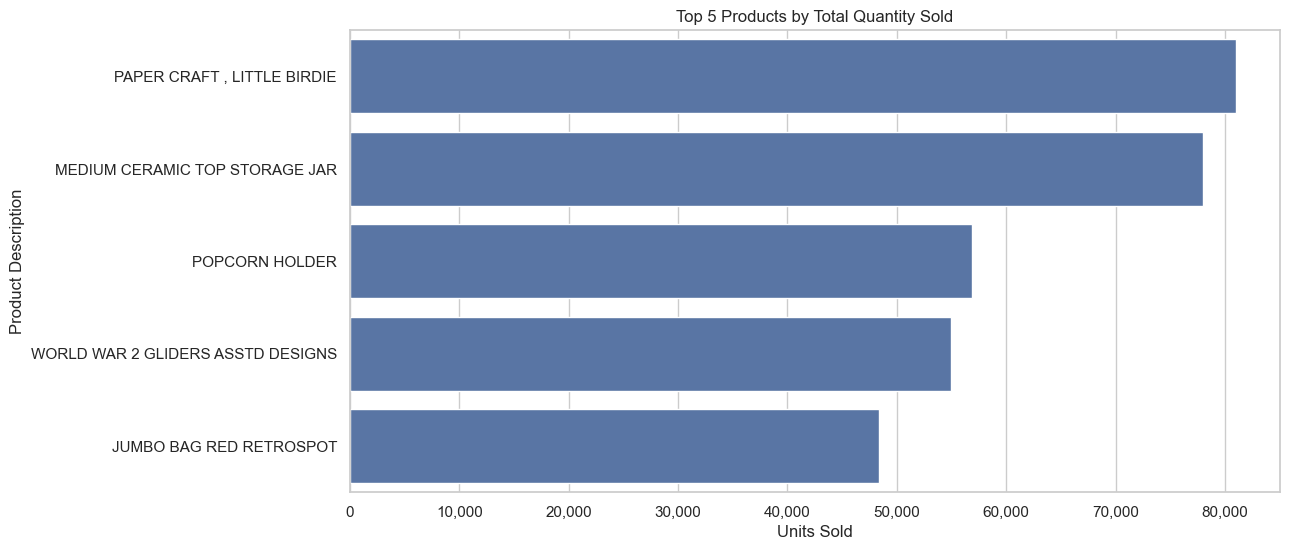

In [43]:
plt.figure(figsize=(12, 6))

sns.barplot(data=top_products_quantity, x="sum", y="Description")
quantity_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().xaxis.set_major_formatter(quantity_formatter)
plt.title("Top 5 Products by Total Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Description")
plt.show()


PAPER CRAFT, LITTLE BIRDIE records the highest total sales volume at 80,995 units, followed by MEDIUM CERAMIC TOP STORAGE JAR at 78,033 units. However, these rankings are heavily influenced by unusually large individual orders, with the largest transaction accounting for 100% and 95.11% of their respective total sales volumes. In comparison, the remaining top products have much lower largest-order percentages, suggesting that their sales volumes are distributed more broadly across transactions.

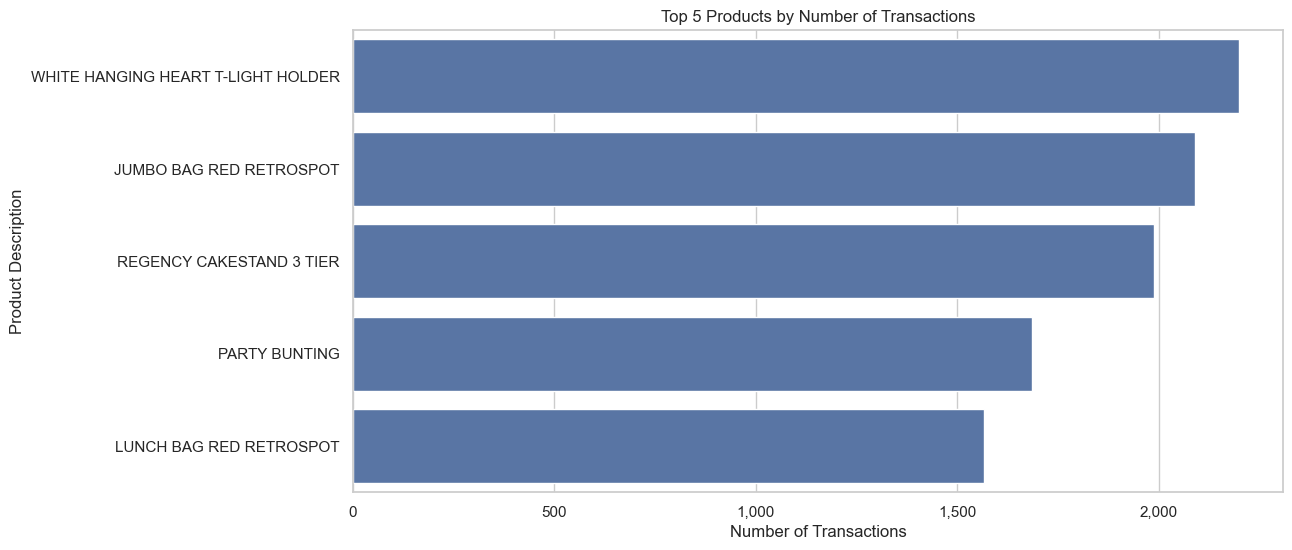

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(data=product_transactions, x="InvoiceNo", y="Description")
transaction_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().xaxis.set_major_formatter(transaction_formatter)
plt.title("Top 5 Products by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.show()

Analysis of transaction frequency shows a different pattern from total sales volume. WHITE HANGING HEART T-LIGHT HOLDER appeared in the greatest number of unique transactions at 2,198, followed by JUMBO BAG RED RETROSPOT at 2,089 and REGENCY CAKESTAND 3 TIER at 1,988. The two products with the highest total quantities sold do not appear among the products with the highest transaction frequency, supporting the earlier finding that their sales volumes were heavily influenced by unusually large individual orders. JUMBO BAG RED RETROSPOT appears in both top-five rankings, indicating both high overall sales volume and frequent purchasing across transactions.

In [45]:
top_products_revenue = (
    df.groupby("StockCode")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
    .head()
)
top_products_revenue

,StockCode,Revenue
3911,DOT,206248.77
1310,22423,174156.54
2465,23843,168469.60
3407,85123A,104462.75
2670,47566,99445.23


In [46]:
df[df["StockCode"] == "DOT"]["Description"].unique()

array(['DOTCOM POSTAGE'], dtype=object)

In [47]:
top_products_revenue = (
    df[df["StockCode"] != "DOT"]
    .groupby("StockCode")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
    .head()
)

top_products_revenue

,StockCode,Revenue
1310,22423,174156.54
2465,23843,168469.60
3407,85123A,104462.75
2670,47566,99445.23
3387,85099B,94159.81


DOT was identified as DOTCOM POSTAGE and represents postage charges rather than a merchandise product. It was therefore excluded from the product revenue ranking to ensure the comparison reflects revenue generated by products.

In [48]:
top_products_revenue = top_products_revenue.merge(product_descriptions, on="StockCode")

top_products_revenue

,StockCode,Revenue,Description
0,22423,174156.54,REGENCY CAKESTAND 3 TIER
1,23843,168469.60,"PAPER CRAFT , LITTLE BIRDIE"
2,85123A,104462.75,WHITE HANGING HEART T-LIGHT HOLDER
3,47566,99445.23,PARTY BUNTING
4,85099B,94159.81,JUMBO BAG RED RETROSPOT


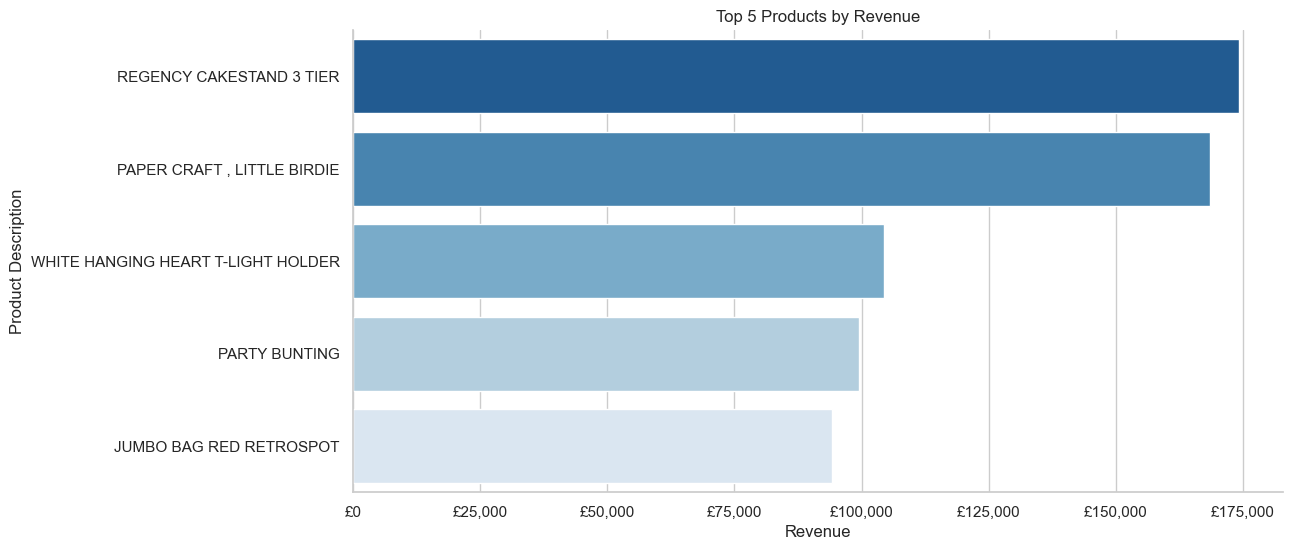

In [49]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description",
    hue="Description",
    palette="Blues_r",
    legend=False,
)

revenue_formatter = FuncFormatter(lambda x, _: f"£{x:,.0f}")
plt.gca().xaxis.set_major_formatter(revenue_formatter)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Description")

sns.despine()
plt.show()

REGENCY CAKESTAND 3 TIER generated the highest product revenue at approximately £174,157, followed by PAPER CRAFT, LITTLE BIRDIE at approximately £168,470. However, the revenue generated by PAPER CRAFT, LITTLE BIRDIE resulted from a single unusually large transaction, meaning its high revenue does not represent repeated customer demand. JUMBO BAG RED RETROSPOT appears within the top five products across total quantity sold, transaction frequency and revenue, indicating consistently strong performance across multiple measures.

---

# Section 6 - Customer Analysis

In this section, I will analyse customer purchasing behaviour by examining customer revenue, transaction frequency and purchasing activity. This will help identify high-value and frequently purchasing customers and determine whether customer performance is concentrated among a small number of customers.

In [50]:
top_customers_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head()
)

top_customers_revenue

,CustomerID,Revenue
2159,15287,1755388.60
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194390.79
3008,16446,168472.50


In [51]:
df[df["CustomerID"] == 15287]["InvoiceNo"].nunique()

1430

In [52]:
df[df["CustomerID"] == 15287].groupby("InvoiceNo")["Revenue"].sum().sort_values(
    ascending=False
).head()

InvoiceNo
574941    52940.94
576365    50653.91
548203    21627.72
539750    18745.86
573585    16874.58
Name: Revenue, dtype: float64

In [ ]:
top_customers_revenue["CustomerID"] = top_customers_revenue["CustomerID"].astype(str)

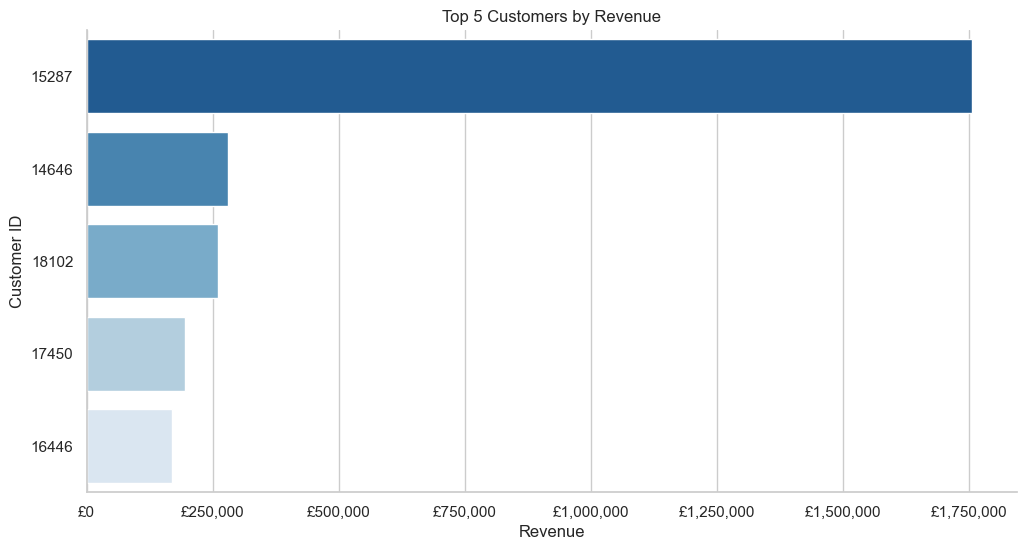

In [54]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_customers_revenue,
    x="Revenue",
    y="CustomerID",
    hue="CustomerID",
    palette="Blues_r",
    legend=False,
)

plt.title("Top 5 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.gca().xaxis.set_major_formatter(revenue_formatter)

sns.despine()

plt.show()

Customer 15287 generated the highest total revenue at approximately £1.76 million, substantially exceeding the other top customers. Further investigation showed that this customer appeared across 1,430 unique transactions, with their largest individual transaction generating approximately £52,941. This indicates that their high total revenue is not driven by a single unusually large transaction, but reflects substantial repeated purchasing activity. Customer 14646 generated the second-highest revenue at approximately £280,206, followed by customer 18102 at approximately £259,657.

In [55]:
top_customers_transactions = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
    .head()
)
top_customers_transactions

,CustomerID,InvoiceNo
2159,15287,1430
326,12748,209
1879,14911,201
4010,17841,124
562,13089,97


In [ ]:
top_customers_transactions["CustomerID"] = top_customers_transactions[
    "CustomerID"
].astype(str)

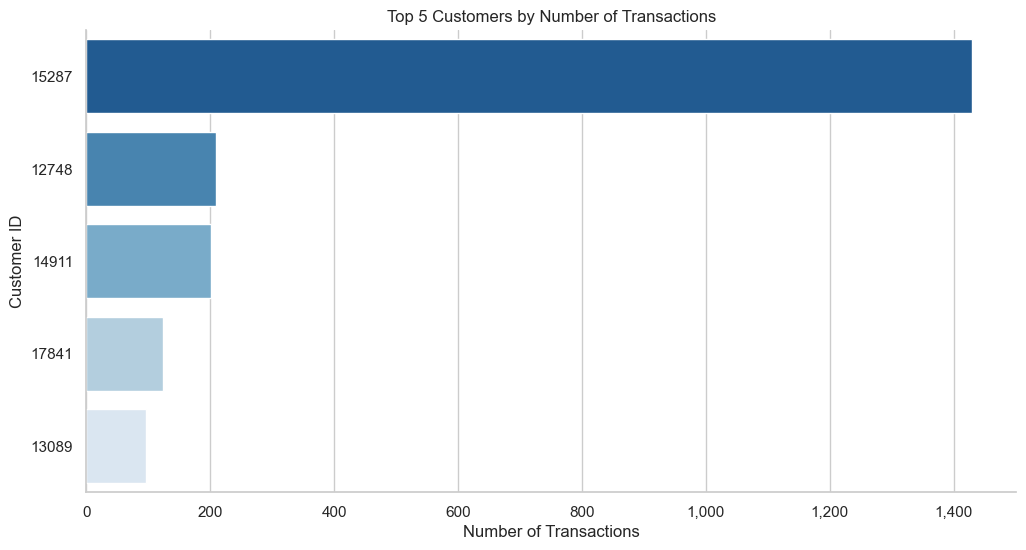

In [57]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_customers_transactions,
    x="InvoiceNo",
    y="CustomerID",
    hue="CustomerID",
    palette="Blues_r",
    legend=False,
)
plt.title("Top 5 Customers by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Customer ID")
plt.gca().xaxis.set_major_formatter(transaction_formatter)
sns.despine()
plt.show()

Customer 15287 has the highest transaction frequency, appearing across 1,430 unique transactions, substantially exceeding customer 12748 in second place with 209 transactions. Customer 15287 also generated the highest total revenue, indicating that their high customer value is supported by substantial repeat purchasing activity rather than a single unusually large transaction. The remaining customers with the highest transaction frequencies differ from those ranked highest by revenue, suggesting that frequent purchasing does not necessarily result in the highest overall customer revenue.

In [ ]:
customer_transactions = (
    df.groupby(["CustomerID", "InvoiceNo"])["Revenue"].sum().reset_index()
)

customer_transactions

,CustomerID,InvoiceNo,Revenue
0,12346,541431,77183.60
1,12347,537626,711.79
2,12347,542237,475.39
3,12347,549222,636.25
4,12347,556201,382.52
...,...,...,...
19955,18283,579673,220.31
19956,18283,580872,208.00
19957,18287,554065,765.28
19958,18287,570715,1001.32


In [59]:
top_customers_avg_transaction = (
    customer_transactions.groupby("CustomerID")["Revenue"]
    .mean()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head()
)

top_customers_avg_transaction

,CustomerID,Revenue
3008,16446,84236.250000
0,12346,77183.600000
2502,15749,14844.766667
2011,15098,13305.500000
10,12357,6207.670000


In [60]:
customer_transactions[
    customer_transactions["CustomerID"].isin(
        top_customers_avg_transaction["CustomerID"]
    )
]

,CustomerID,InvoiceNo,Revenue
0,12346,541431,77183.60
28,12357,574740,6207.67
9018,15098,556442,297.00
9019,15098,556444,38970.00
9020,15098,556446,649.50
12323,15749,540815,15160.90
12324,15749,540818,7837.50
12325,15749,550461,21535.90
14315,16446,553573,2.90
14316,16446,581483,168469.60


The customers with the highest average transaction values were investigated further to determine whether these averages reflected consistent purchasing behaviour. The results showed that these customers generally had very few transactions, with some averages heavily influenced by a single high-value purchase. Therefore, average transaction value was not used as a primary measure of customer performance, as it may overstate the importance of customers with limited purchasing history.

Overall, customer performance is highly concentrated around customer 15287, who leads both revenue and transaction frequency, while the analysis also demonstrates that high average transaction values should be interpreted cautiously when customers have limited purchasing histories.